In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append("../") # Add parent directory to path
from mfbox import gokunet_df_ratio, gokunet_df_pca_in
from scipy.interpolate import interp1d

In [2]:
# Check if GPU is available
device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


In [3]:
zs_obj = [0, 0.2, 0.5, 1, 2, 3]
# remove duplicates
zs_obj = np.unique(zs_obj)

In [4]:
# load input data
x_test = np.loadtxt("../data/muse_H/train_input.txt")
lgk_test = np.loadtxt("../data/muse_H/kf.txt")
k_test = 10**lgk_test

n_k = len(lgk_test)
n_z = len(zs_obj)

# normalize input data
# bounds = np.loadtxt("../data/narrow/matter_power_564_Box250_Part750_15_Box1000_Part3000_z0/input_limits.txt")
bounds_path = "../data/input_limits-W.txt"
# x_test = (x_test - bounds[:,0]) / (bounds[:,1] - bounds[:,0])

y_test = np.loadtxt("../data/muse_H/train_output.txt")
# reshape y_test to match the number of k values and z values
# y_test = y_test[:, i_z*n_k:(i_z+1)*n_k]
y_test = y_test.reshape(-1, n_z, n_k)

y_test = 10**y_test

ind_h = [24, 25, 26, 54, 55, 56, 72, 73, 74, 207, 208, 209, 240, 241, 242, 300, 301, 302, 522, 523, 524]


lgk_l2 = np.loadtxt("../data/muse_L2/kf.txt")
k_l2 = 10**lgk_l2
n_k_l2 = len(lgk_l2)
y_l2 = np.loadtxt("../data/muse_L2/train_output.txt")
y_l2 = 10**y_l2[ind_h]
y_l2 = y_l2.reshape(-1, n_z, n_k_l2)

x_xy_pca_test = np.loadtxt("../data/muse_L2H_pca_l/train_input.txt")




In [5]:
y_test.shape

(21, 6, 64)

In [6]:
def power_ratio(k, y_pred, k_test, y_test):

    # find the indices of k_common in k_test
    k_indices = np.where((k_test >= k.min()) & (k_test < k.max()))[0]
    k_common = k_test[k_indices]
    y_test_common = y_test[k_indices]

    # interpolate the values of y_pred at the k_common points in log space
    f = interp1d(np.log10(k), np.log10(y_pred), axis=0, kind='linear')
    y_pred_interp = f(np.log10(k_common))
    # convert back to linear space
    y_pred_interp = 10**y_pred_interp

    # calculate the ratio
    ratio = y_pred_interp / y_test_common
    print("y_test_common", y_test_common)
    print("y_pred_interp", y_pred_interp)

    return k_common, ratio


In [7]:


def rel_MAEs(x1, y1, x2, y2):
    # Transform x1, x2, y1, and y2 into log10 space
    log10_x1 = np.log10(x1)
    log10_x2 = np.log10(x2)
    log10_y1 = np.log10(y1)
    log10_y2 = np.log10(y2)

    # Define the common log10(x) range for interpolation
    common_log10_x_min = max(min(log10_x1), min(log10_x2))
    common_log10_x_max = min(max(log10_x1), max(log10_x2))
    ind_com = np.where((log10_x1 >= common_log10_x_min) & (log10_x1 <= common_log10_x_max) )

    common_log10_x = log10_x1[ind_com]

    # Interpolate log10_y1 and log10_y2 to the common log10_x grid
    interp_log10_y1 = interp1d(log10_x1, log10_y1, kind='linear')(common_log10_x)
    interp_log10_y2 = interp1d(log10_x2, log10_y2, kind='linear')(common_log10_x)

    # Transform interpolated log10 values back to the original space
    interp_y1 = 10**interp_log10_y1
    interp_y2 = 10**interp_log10_y2
    common_x = 10**common_log10_x  # Transform common_log10_x back to original x values

    # Compute (y2 - y1) / y1 in original space
    rMAE_y = np.abs((interp_y2 / interp_y1) - 1)
    return common_x, rMAE_y

def rMAE_av_cosmo(k_test, y_test, k_pred, y_pred, exclude=None):
    Ps_pred = y_pred
    Ps_sim = y_test
    k_sim = k_test
    k, rAEs = rel_MAEs(k_sim, Ps_sim, k_pred, Ps_pred)
    if exclude is not None:  # exclude some cosmologies
        rAEs = np.delete(rAEs, exclude, axis=0)
    rMAE_av = np.mean(rAEs, axis=0)

    # rAE_av_k = np.mean(rAEs, axis=1)

    # min and max
    rMAE_min, rMAE_max = np.min(rAEs, axis=0), np.max(rAEs, axis=0)
    return k, rMAE_av, rMAE_min, rMAE_max, rAEs

In [8]:
# NNL-2
# loop over all k-folds to get the prediction
y_l2_pred_2 = []
kfolds = 21

for i in range(kfolds):
    emu = gokunet_df_ratio(path_LF="../models/muse-NNL-2_L2/model_fold{}.pth".format(ind_h[i]), path_LHr="../models/muse-HO-3_L2Hr/model_fold{}.pth".format(i), bounds_path=bounds_path, device=device)
    # emu = gokunet_test(path_LA="../models/L1A/model_fold{}.pth".format(ind_h[i]),path_HA="../models/LHAr/model_fold{}.pth".format(i), path_L2="../models/L2/model_fold{}.pth".format(ind_h[i]), path_LH="../models/LHr_stitch/best_model.pth".format(i), bounds_path=bounds_path)
    _, y_l2_pred_temp = emu.predict_LF(x_test)
    y_l2_pred_2.append(y_l2_pred_temp[i])

y_l2_pred_2 = np.array(y_l2_pred_2)
y_l2_pred_2 = y_l2_pred_2.reshape(-1, n_z, n_k_l2)



In [17]:
# NNL-3
y_l2_pred_3 = []
kfolds = 21

for i in range(kfolds):
    emu = gokunet_df_ratio(path_LF="../models/muse-NNL-3_L2/model_fold{}.pth".format(ind_h[i]), path_LHr="../models/L2Hr/best_model.pth", bounds_path=bounds_path, device=device)
    # emu = gokunet_test(path_LA="../models/L1A/model_fold{}.pth".format(ind_h[i]),path_HA="../models/LHAr/model_fold{}.pth".format(i), path_L2="../models/L2/model_fold{}.pth".format(ind_h[i]), path_LH="../models/LHr_stitch/best_model.pth".format(i), bounds_path=bounds_path)
    _, y_l2_pred_temp = emu.predict_LF(x_test)
    y_l2_pred_3.append(y_l2_pred_temp[i])

y_l2_pred_3 = np.array(y_l2_pred_3)
y_l2_pred_3 = y_l2_pred_3.reshape(-1, n_z, n_k_l2)


In [18]:
# Mid
y_l2_pred_M = []
kfolds = 21

for i in range(kfolds):
    emu = gokunet_df_ratio(path_LF="../models/muse-HO-3_L2/model_fold{}.pth".format(ind_h[i]), path_LHr="../models/muse-HO-3_L2Hr/best_model.pth", bounds_path=bounds_path, device=device)
    # predict ratio
    _, y_l2_pred_temp = emu.predict_LF(x_test)
    y_l2_pred_M.append(y_l2_pred_temp[i])

y_l2_pred_M = np.array(y_l2_pred_M)
y_l2_pred_M = y_l2_pred_M.reshape(-1, n_z, n_k_l2)


In [19]:
def plot_ax_1(ax, k_test, y_test, k_l2, y_h2_pred, zs_obj, color, ls_list, label=False):
    rMAE_cosmos = []

    for i in range(len(zs_obj)):
        c = color

        k_com, rMAE, rMAE_min, rMAE_max, rAEs = rMAE_av_cosmo(k_test, y_test[:,i], k_l2, y_h2_pred[:,i], exclude=None)
        print('average over k:', rMAE.mean())
        rMAE_cosmos.append(rMAE.mean())

    # plot only i = 0, 3, 5
        if i not in [0, 3, 5]:
            continue

        if label:
            ax.plot(k_com, rMAE/1e-2, color=c, ls=ls_list[i], label=f'$z={zs_obj[i]:.1f}$')
        else:
            ax.plot(k_com, rMAE/1e-2, color=c, ls=ls_list[i])

        
    ax.set_xscale('log')
    ax.set_xlabel(r'$k\ (h\,\mathrm{Mpc}^{-1})$')
    rMAE_cosmos = np.array(rMAE_cosmos)

    xlim1 = .02
    xlim2 = 10
    ax.set_xlim(xlim1, xlim2)
    

    # title
    # ax.set_title(name + f' ({100*rMAE_cosmos.mean():.2f}%)')
    ax.grid(True)

    return rMAE_cosmos

average over k: 0.011412053587715802
average over k: 0.010477413103326358
average over k: 0.010014562307500242
average over k: 0.008971954937218498
average over k: 0.00889971964456071
average over k: 0.008667527362173372
average over k: 0.005965955741302482
average over k: 0.005564394944922766
average over k: 0.005426296110626434
average over k: 0.005316255067765811
average over k: 0.00512626454458549
average over k: 0.0054109627696807125
average over k: 0.00883401179655644
average over k: 0.008071930840699376
average over k: 0.0074548125361529605
average over k: 0.0073015263942247475
average over k: 0.006917747397004983
average over k: 0.006114834472071523
NNL-2 rMAE: 0.5468354863147282
NNL-3 rMAE: 0.7449143906118338
Mid rMAE: 0.9740538490415831


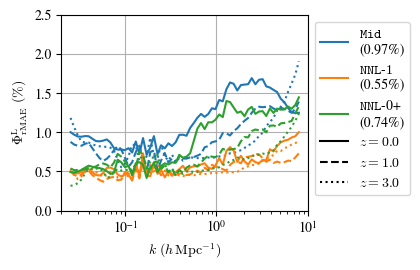

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(4.3, 2.8))

# cmap = "viridis"
# cmap = plt.get_cmap(cmap)
# color_list = [x for x in cmap(np.arange(len(zs_obj))/(len(zs_obj)-1))]
plt.rcParams['font.family'] = 'Nimbus Roman'

# Set math font style
plt.rcParams['mathtext.fontset'] = 'cm'

ls_list = ['-', '--', '-.', '--', '-', ':']

# label the ls
ax.plot([], [], color='C0', label=r'$\tt{Mid}$' + ' \n(0.97%)')
ax.plot([], [], color='C1', label=r'$\tt{NNL}$'+'-'+r'$\tt{1}$' + ' \n(0.55%)')
ax.plot([], [], color='C2', label=r'$\tt{NNL}$'+'-'+'0+' + ' \n(0.74%)')

rMAE_cosmos_Mid = plot_ax_1(ax, k_test, y_l2, k_l2, y_l2_pred_M, zs_obj, 'C0', ls_list=ls_list)

rMAE_cosmos_NNL2 = plot_ax_1(ax, k_test, y_l2, k_l2, y_l2_pred_2, zs_obj, 'C1', ls_list=ls_list)

rMAE_cosmos_NNL3 = plot_ax_1(ax, k_test, y_l2, k_l2, y_l2_pred_3, zs_obj, 'C2', ls_list=ls_list)



# label the colors
for i, z in enumerate(zs_obj):
    if i not in [0, 3, 5]:
        continue
    ax.plot([], [], color='black', ls=ls_list[i], label=f'$z={z:.1f}$')

# print the average rMAE for both models
print('NNL-2 rMAE:', 100 * rMAE_cosmos_NNL2.mean())
print('NNL-3 rMAE:', 100 * rMAE_cosmos_NNL3.mean())
print('Mid rMAE:', 100 * rMAE_cosmos_Mid.mean())

ax.set_ylim(0, 2.5)

ax.set_ylabel(r'$\Phi_{\mathrm{rMAE}}^{\mathrm{L}}\ (\%)$')

# ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=8)
ax.legend(loc='best', bbox_to_anchor=(1.0, 1)) # outside the plot

# save
plt.tight_layout()
# plt.savefig("Mid-NNL-1_NNL-0+_rMAE.pdf", bbox_inches='tight')

